This is the initial simulation, \vers{I} is assumed to be in the x-y plane for dim=2 and x-z for dim=3.
In this plane [0,-1,0] is the psi=0 direction.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# import numba as nb

In [2]:
# System parameters

dim = 2

D_n = 0.067 # realistic value
D_r = 0.
V0 = 1.
w0 = 0. # realistic value = 1, w0 = 0 for benchmark

epsilon = 10**(-3)

vec_I = np.zeros(dim)
vec_I[-1] = -1

In [3]:
# Simulation parameters

N_samples = 10**4
nt = 2000 #800    # number of times steps

dt = 5*10**-2
if not dt < 0.01 / D_n:
    raise Exception("too large time step")

In [4]:
r0 = np.zeros((dim, N_samples))

n0 = np.zeros((dim,N_samples))
n0[0,:] = 1 # n0[-1,:] = 1

r = np.copy(r0) # initial position
n = np.copy(n0) # initial orientation

In [5]:
# Tensor for saving positions
r_history = np.zeros((nt+1, dim, N_samples))
r_history[0,:,:] = r0

n_history = np.zeros((nt+1, dim, N_samples))
n_history[0,:,:] = n0

In [6]:
zeta_n = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))
zeta_r = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))

dn_rand = np.sqrt(2*D_n*dt)*zeta_n
dr_rand = np.sqrt(2*D_r*dt)*zeta_r

In [7]:
# Time evolution

for it in range(nt):
    
    dn = dn_rand[it,:,:] # noise term
    dn -= n*np.sum(n*dn, axis=0) # project onto tangent space

    n += dn
    n /= np.linalg.norm(n, axis=0)
    
    r = n*V0*dt + r + dr_rand[it,:]
    r_history[it+1,:,:] = r
    n_history[it+1,:,:] = n

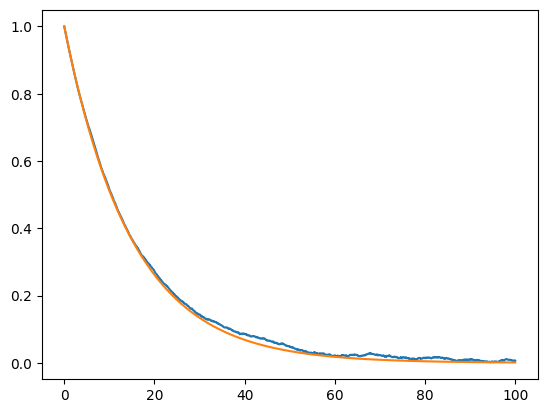

In [8]:
# Computing correlator 1

def correlator_benchmark1(dim, t):
    if dim == 2:
        return np.exp(-D_n*t)#2*(1-np.exp(-2*D_n*t))
    elif dim == 3: 
        return np.exp(-2*D_n*t)

product_n = n_history*n0[None,:]
sums_n = np.sum(product_n,axis=1)
correlator = np.mean(sums_n, axis=1)

t_steps = dt*np.arange(0,nt+1)

plt.plot(t_steps,correlator)
plt.plot(t_steps,correlator_benchmark1(dim, t_steps))
plt.show()

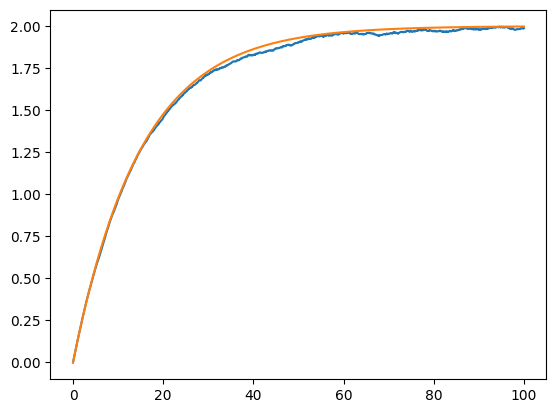

In [ ]:
# Computing correlator 2

def correlator_benchmark2(dim, t):
    if dim == 2:
        return 2*(1-np.exp(-D_n*t))
    elif dim == 3: 
        return 2*(1-np.exp(-2*D_n*t))

Delta_n = n_history-n0[None,:]
sums_n = np.sum(Delta_n**2,axis=1)
correlator2 = np.mean(sums_n, axis=1)

t_steps = dt*np.arange(0,nt+1)

plt.plot(t_steps, correlator2)
plt.plot(t_steps, correlator_benchmark2(dim, t_steps))
plt.show()

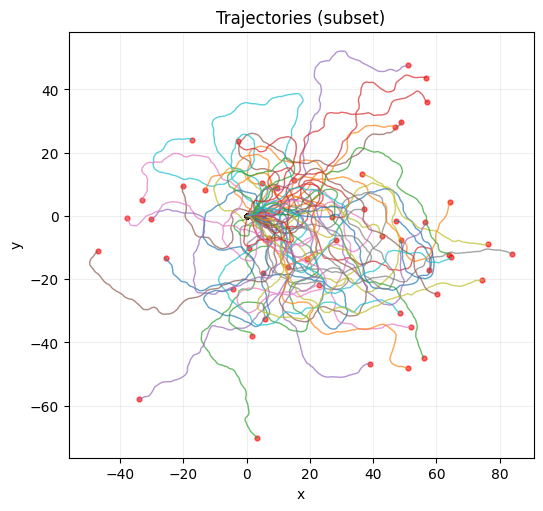

In [10]:
# Visualize trajectories in r_history
# r_history shape: (nt+1, dim, N_samples)

n_show = min(50, N_samples)           # number of trajectories to plot
idx = np.linspace(0, N_samples - 1, n_show, dtype=int)

t = np.arange(r_history.shape[0])

if dim == 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Trajectories (subset)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    plt.show()

elif dim == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], r_history[:, 2, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], r_history[0, 2, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], r_history[-1, 2, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Trajectories (subset)")
    plt.show()

In [11]:
y_final = r_history[-1,0,:]
if_positive = y_final>0
if_negative = y_final<0
n_positive = np.sum(if_positive)
n_negative = np.sum(if_negative)
print(n_negative, n_positive)

3303 6697
